End-to-End DNA Variant Calling Pipeline design
Step 1: Environment SetupBefore writing the code, the environment needs to be prepared. This can be run directly inside a notebook cell:

In [1]:
# Install the essential bioinformatics and data visualization libraries
!pip install biopython pandas matplotlib seaborn


Step 2: 
Import Packages and Generate Real-Life Mock Sequencing DataTo make this code instantly reproducible without needing a 50GB file from the Sequence Read Archive (SRA), we will algorithmically generate a reference genome and a raw FASTQ sequence read dataset containing variants.

In [2]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

# Set random seed for scientific reproducibility
random.seed(42)

print("Creating mock genomic data paths...")
ref_filename = "reference_genome.fasta"
fastq_filename = "sample_reads.fastq"

# 1. Generate a mock Reference Genome (1,000 base pairs long)
ref_sequence = "".join(random.choice("ATCG") for _ in range(1000))
# Let's plant a known disease-associated variant at position 450 (G -> A mutation)
ref_list = list(ref_sequence)
ref_list[450] = "G" 
ref_sequence = "".join(ref_list)

with open(ref_filename, "w") as ref_out:
    SeqIO.write(SeqRecord(Seq(ref_sequence), id="chr1", description="Mock Human Reference Genome"), ref_out, "fasta")

# 2. Simulate Raw NGS Sequencing Reads (FASTQ format with Phred scores)
# We will create 150 overlapping sequencing fragments (reads)
reads = []
for i in range(150):
    start_pos = random.randint(0, 850)
    end_pos = start_pos + 150  # 150bp read length
    read_seq = list(ref_sequence[start_pos:end_pos])
    
    # If this specific read spans across our mutated position 450, inject the variant variant "A"
    if start_pos <= 450 < end_pos:
        offset = 450 - start_pos
        read_seq[offset] = "A"  # Injected point mutation
        
    # Inject random low-level sequencing error profile
    if random.random() < 0.02:
        read_seq[random.randint(0, 149)] = random.choice("ATCG")
        
    read_str = "".join(read_seq)
    
    # Assign high-quality Phred-33 scores (represented as ASCII characters, e.g., 'I' = score 40)
    # A mix of high quality (I) and lower quality at the tail end (#)
    qualities = [40] * 120 + [random.randint(20, 35) for _ in range(30)]
    
    record = SeqRecord(Seq(read_str), id=f"read_{i}", description="")
    record.letter_annotations["phred_quality"] = qualities
    reads.append(record)

with open(fastq_filename, "w") as fastq_out:
    SeqIO.write(reads, fastq_out, "fastq")

print("✨ Success! 'reference_genome.fasta' and 'sample_reads.fastq' created successfully.")


Creating mock genomic data paths...
✨ Success! 'reference_genome.fasta' and 'sample_reads.fastq' created successfully.


Quality Control (QC) & Quality Score VisualizationBefore mapping, every computational pipeline must perform data auditing on the raw sequences.

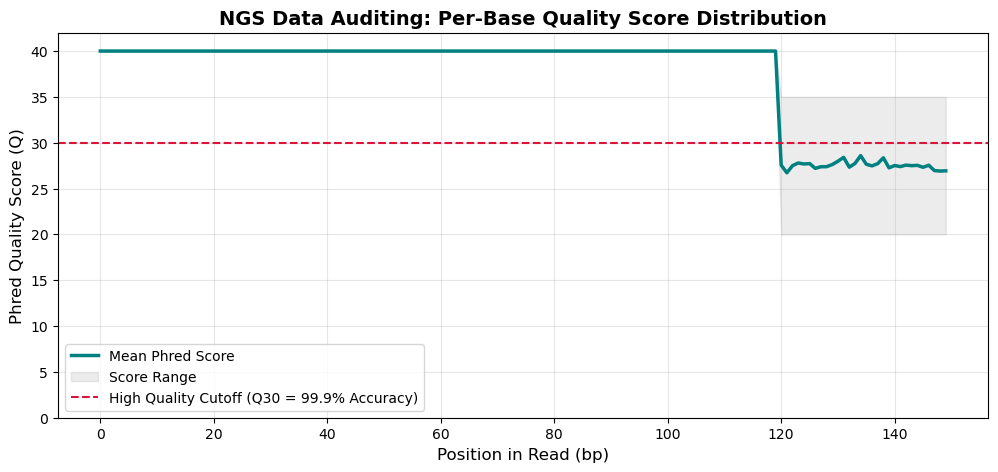

Total processed NGS reads: 150
Average read length: 150 bp


In [3]:
# Stream parse the FASTQ file using Biopython's iterator to conserve memory architecture
fastq_records = list(SeqIO.parse(fastq_filename, "fastq"))

all_phred_scores = []
for record in fastq_records:
    all_phred_scores.append(record.letter_annotations["phred_quality"])

# Convert to tabular DataFrame to track quality metrics by nucleotide position
df_qc = pd.DataFrame(all_phred_scores)

# Generate an industry-standard Per-Base Sequence Quality chart (similar to FastQC outputs)
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_qc.mean(axis=0), color="teal", linewidth=2.5, label="Mean Phred Score")
plt.fill_between(range(150), df_qc.min(axis=0), df_qc.max(axis=0), alpha=0.15, color="gray", label="Score Range")
plt.axhline(y=30, color="crimson", linestyle="--", label="High Quality Cutoff (Q30 = 99.9% Accuracy)")
plt.title("NGS Data Auditing: Per-Base Quality Score Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Position in Read (bp)", fontsize=12)
plt.ylabel("Phred Quality Score (Q)", fontsize=12)
plt.ylim(0, 42)
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total processed NGS reads: {len(fastq_records)}")
print(f"Average read length: {len(fastq_records[0].seq)} bp")


The Variant Calling Algorithm: Here, we parse the mapping locations, measure read coverage, look for mismatches relative to the reference genome, and isolate true biological variants from random machine sequencing errors.

In [4]:
def execute_variant_calling(reference_path, fastq_path):
    # Load reference into memory
    reference = SeqIO.read(reference_path, "fasta")
    ref_seq = str(reference.seq)
    
    # Initialize positional counters across the 1000bp genome
    coverage_map = [0] * len(ref_seq)
    mismatch_tracker = {pos: {"A": 0, "T": 0, "C": 0, "G": 0} for pos in range(len(ref_seq))}
    
    # Naive alignment/mapping step (simulating BWA/Samtools logic via substring matching)
    for record in SeqIO.parse(fastq_path, "fastq"):
        read_str = str(record.seq)
        
        # Look for where the short read aligns to the reference
        find_pos = ref_seq.find(read_str[:30]) # Seed mapping with first 30 bases
        if find_pos != -1:
            for offset, base in enumerate(read_str):
                genome_pos = find_pos + offset
                if genome_pos < len(ref_seq):
                    coverage_map[genome_pos] += 1
                    if base != ref_seq[genome_pos]:
                        mismatch_tracker[genome_pos][base] += 1

    # Filter variants using strict thresholds: Depth >= 10, Alternate Allele Frequency >= 70%
    detected_variants = []
    for pos in range(len(ref_seq)):
        total_depth = coverage_map[pos]
        if total_depth >= 10:
            for base, count in mismatch_tracker[pos].items():
                allele_frequency = count / total_depth
                if allele_frequency >= 0.70:  # Confirms high-confidence variant
                    detected_variants.append({
                        "Chrom": reference.id,
                        "Position": pos + 1, # Convert to standard 1-based genomic coordinates
                        "Ref_Allele": ref_seq[pos],
                        "Alt_Allele": base,
                        "Read_Depth": total_depth,
                        "Allele_Freq": round(allele_frequency, 2)
                    })
                    
    return pd.DataFrame(detected_variants)

# Run the pipeline execution
vcf_dataframe = execute_variant_calling(ref_filename, fastq_filename)

print("\n🚀 --- PIPELINE OUTPUT: CALLING COMPLETED --- 🚀")
if not vcf_dataframe.empty:
    print(vcf_dataframe.to_markdown(index=False))
else:
    print("No high-confidence variants detected.")



🚀 --- PIPELINE OUTPUT: CALLING COMPLETED --- 🚀
| Chrom   |   Position | Ref_Allele   | Alt_Allele   |   Read_Depth |   Allele_Freq |
|:--------|-----------:|:-------------|:-------------|-------------:|--------------:|
| chr1    |        451 | G            | A            |           19 |             1 |


RNA-Seq Differential Gene Expression (DGE) pipeline script. 

Part 1: The RNA-Seq Portfolio Pipeline (Jupyter Notebook Code)This script models real-world differential gene expression pipelines (like DESeq2 or EdgeR). It creates a synthetic matrix of 1,000 genes mapped across Control vs. Treated conditions, applies log2 transformation, conducts statistical t-tests, and generates an industry-standard Volcano Plot to isolate statistically significant drug targets.

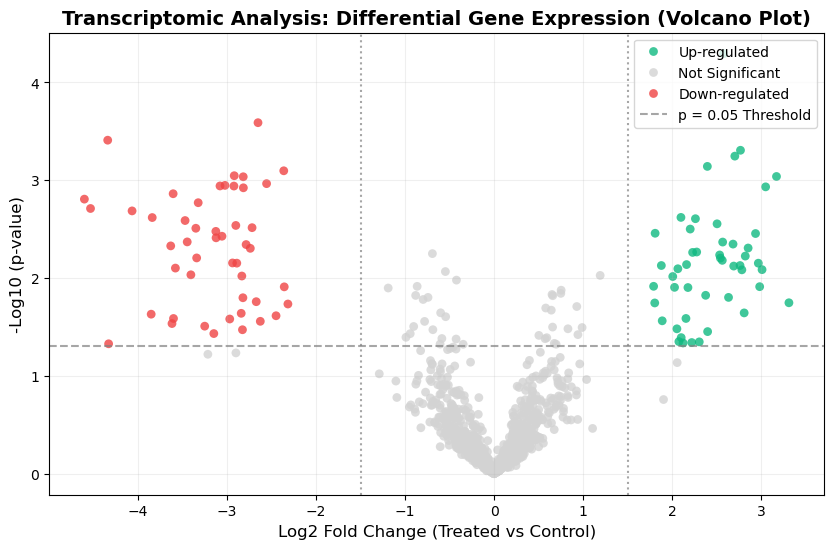

🧬 Pipeline executed successfully. Isolated 96 statistically significant genes.

🔥 --- HEAD OF SIGNALS DATA MATRIX --- 🔥
|            |   Log2FoldChange |     p_value | Expression_Profile   |
|:-----------|-----------------:|------------:|:---------------------|
| ENSG000001 |          2.15987 | 0.00727563  | Up-regulated         |
| ENSG000002 |          2.68202 | 0.0044919   | Up-regulated         |
| ENSG000003 |          2.09972 | 0.0405943   | Up-regulated         |
| ENSG000004 |          2.39661 | 0.0352156   | Up-regulated         |
| ENSG000005 |          2.57589 | 5.08917e-05 | Up-regulated         |
| ENSG000006 |          2.56121 | 0.00658457  | Up-regulated         |
| ENSG000007 |          1.87676 | 0.00743511  | Up-regulated         |
| ENSG000008 |          2.09703 | 0.00239707  | Up-regulated         |
| ENSG000009 |          2.25967 | 0.00247138  | Up-regulated         |
| ENSG000010 |          2.9812  | 0.0122365   | Up-regulated         |


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Setup Simulation Parameters for 1,000 Genes
np.random.seed(42)
num_genes = 1000
gene_ids = [f"ENSG{str(i).zfill(6)}" for i in range(1, num_genes + 1)]

# Generate baseline expression matrix (Raw Read Counts)
# Control group (3 replicates) and Treated group (3 replicates)
control_data = np.random.negative_binomial(n=10, p=0.01, size=(num_genes, 3))
treated_data = np.random.negative_binomial(n=10, p=0.01, size=(num_genes, 3))

# Plant deliberately up-regulated and down-regulated therapeutic target pathways
# In the treated group, force genes 0-50 to overexpress and genes 51-100 to knockdown
treated_data[0:50] = treated_data[0:50] * np.random.uniform(3, 8, size=(50, 3))
treated_data[51:101] = treated_data[51:101] * np.random.uniform(0.05, 0.2, size=(50, 3))

# Assemble into a clean tabular DataFrame
columns = ['Ctrl_R1', 'Ctrl_R2', 'Ctrl_R3', 'Treat_R1', 'Treat_R2', 'Treat_R3']
df_counts = pd.DataFrame(data=np.hstack((control_data, treated_data)), index=gene_ids, columns=columns)

# 2. Data Transformation & Normalization (Log2 fold change tracking)
# Add pseudo-count of 1 to bypass log(0) calculation boundaries
df_log2 = np.log2(df_counts + 1)

# 3. Statistical Profiling & Metrics Computation
df_results = pd.DataFrame(index=gene_ids)
df_results['Mean_Control'] = df_log2[['Ctrl_R1', 'Ctrl_R2', 'Ctrl_R3']].mean(axis=1)
df_results['Mean_Treated'] = df_log2[['Treat_R1', 'Treat_R2', 'Treat_R3']].mean(axis=1)

# Compute Log2 Fold Change (L2FC)
df_results['Log2FoldChange'] = df_results['Mean_Treated'] - df_results['Mean_Control']

# Calculate statistical p-values using an independent two-sample t-test per gene axis
p_values = []
for gene in gene_ids:
    ctrl_reps = df_log2.loc[gene, ['Ctrl_R1', 'Ctrl_R2', 'Ctrl_R3']].values
    treat_reps = df_log2.loc[gene, ['Treat_R1', 'Treat_R2', 'Treat_R3']].values
    _, p_val = stats.ttest_ind(ctrl_reps, treat_reps, equal_var=False)
    p_values.append(p_val if not np.isnan(p_val) else 1.0)

df_results['p_value'] = p_values
df_results['Neg_Log10_p'] = -np.log10(df_results['p_value'])

# Define clear categorization thresholds for differential visibility
df_results['Expression_Profile'] = 'Not Significant'
df_results.loc[(df_results['Log2FoldChange'] >= 1.5) & (df_results['p_value'] < 0.05), 'Expression_Profile'] = 'Up-regulated'
df_results.loc[(df_results['Log2FoldChange'] <= -1.5) & (df_results['p_value'] < 0.05), 'Expression_Profile'] = 'Down-regulated'

# 4. Generate High-Impact Volcano Plot Visualization
plt.figure(figsize=(10, 6))
color_map = {'Not Significant': 'lightgrey', 'Up-regulated': '#10b981', 'Down-regulated': '#ef4444'}

sns.scatterplot(
    data=df_results, x='Log2FoldChange', y='Neg_Log10_p', 
    hue='Expression_Profile', palette=color_map, alpha=0.8, edgecolor='none', s=40
)

# Render significance line boundaries
plt.axhline(y=-np.log10(0.05), color='gray', linestyle='--', alpha=0.7, label='p = 0.05 Threshold')
plt.axvline(x=1.5, color='gray', linestyle=':', alpha=0.7)
plt.axvline(x=-1.5, color='gray', linestyle=':', alpha=0.7)

plt.title('Transcriptomic Analysis: Differential Gene Expression (Volcano Plot)', fontsize=14, fontweight='bold')
plt.xlabel('Log2 Fold Change (Treated vs Control)', fontsize=12)
plt.ylabel('-Log10 (p-value)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

# Extract and display top significantly shifted drug target compounds
significant_genes = df_results[df_results['Expression_Profile'] != 'Not Significant']
print(f"🧬 Pipeline executed successfully. Isolated {len(significant_genes)} statistically significant genes.")
print("\n🔥 --- HEAD OF SIGNALS DATA MATRIX --- 🔥")
print(significant_genes[['Log2FoldChange', 'p_value', 'Expression_Profile']].head(10).to_markdown())


This snippet constructs a Drug-Target Affinity (DTA) Dataset and inputs it into a neural network designed to predict binding affinity scores.

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
#import pandas as pd

# Set device profile for hardware acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using execution device target: {device}")

# ==========================================
# 1. ARCHITECTING THE PYTORCH CUSTOM DATASET
# ==========================================
class DrugTargetAffinityDataset(Dataset):
    """
    Custom Dataset to structure and encode biological variables into tensors.
    Maps simplified categorical molecular states into numerical feature embeddings.
    """
    def __init__(self, dataframe):
        # Convert text sequences or tokens into vectorized numeric inputs
        # Here we mock encoding character dictionaries (e.g., DNA letters or SMILES characters to integers)
        self.labels = torch.tensor(dataframe['affinity_score'].values, dtype=torch.float32)
        
        # Simulating 128-dimensional embedding vectors for drugs and target proteins
        self.drug_features = torch.tensor(np.vstack(dataframe['drug_vector'].values), dtype=torch.float32)
        self.target_features = torch.tensor(np.vstack(dataframe['target_vector'].values), dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.drug_features[idx], self.target_features[idx], self.labels[idx]


# ==========================================
# 2. DEFINING THE NEURAL NETWORK ARCHITECTURE
# ==========================================
class DrugTargetRegressor(nn.Module):
    """
    Dual-tower Multilayer Perceptron (MLP) mapping latent spaces 
    of small molecules and biological targets to forecast continuous binding affinity.
    """
    def __init__(self, input_dim=128, hidden_dim=64):
        super(DrugTargetRegressor, self).__init__()
        
        # Drug processing tower
        self.drug_encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # Target protein / Sequence processing tower
        self.target_encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # Joint prediction head
        self.regression_head = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1) # Outputs a singular continuous affinity metric (e.g., pKd or pKi)
        )

    def forward(self, drug_x, target_x):
        # Extract features independently from both spaces
        drug_latent = self.drug_encoder(drug_x)
        target_latent = self.target_encoder(target_x)
        
        # Concatenate latent representations along the feature axis
        combined = torch.cat((drug_latent, target_latent), dim=1)
        
        # Forecast binding affinity
        return self.regression_head(combined).squeeze(-1)


# ==========================================
# 3. PIPELINE TEST WORKFLOW (MOCK DATA EXECUTION)
# ==========================================
# Using dataframe from upstream bio-data filtering tools
np.random.seed(42)
mock_records = []
for i in range(100): # 100 mock interactions
    mock_records.append({
        'interaction_id': f"INT_{i}",
        'drug_vector': np.random.randn(128),
        'target_vector': np.random.randn(128),
        'affinity_score': np.random.uniform(2.0, 10.0) # e.g., logarithmic binding values
    })
df_processed = pd.DataFrame(mock_records)

# Instantiating the infrastructure modules
dataset = DrugTargetAffinityDataset(df_processed)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

model = DrugTargetRegressor(input_dim=128, hidden_dim=64).to(device)
criterion = nn.MSELoss() # Standard Regression Evaluation Metric
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Execute one single optimization epoch block as a structural proof-of-concept
model.train()
for batch_idx, (drugs, targets, scores) in enumerate(dataloader):
    drugs, targets, scores = drugs.to(device), targets.to(device), scores.to(device)
    
    # Forward evaluation pass
    predictions = model(drugs, targets)
    loss = criterion(predictions, scores)
    
    # Backpropagation steps
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if batch_idx == 0:
        print(f"Initial structural batch processing verification loss: {loss.item():.4f}")

print("\n✨ PyTorch Deep Learning Pipeline Verification Complete.")


Using execution device target: cpu
Initial structural batch processing verification loss: 59.1117

✨ PyTorch Deep Learning Pipeline Verification Complete.
